# Object detection by OpenCV library

## Install OpenCV library

In [ ]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


## Disblay image

In [13]:
import cv2

img = cv2.imread("Cat.jpg")
cv2.imshow("Cat", img)

cv2.waitKey(0)
cv2.destroyAllWindows()

To convert BGR to RGB, we us a function:

In [14]:
import cv2

img = cv2.imread("Cat.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imshow("image", RGB_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [1]:
import cv2

# Load classifiers
cat_face = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalcatface.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# Read image
img = cv2.imread("Cat.jpg")

if img is None:
    print("Image not found!")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect cat face
faces = cat_face.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(60, 60)
)

print("Faces:", len(faces))

for (x, y, w, h) in faces:

    # Draw face
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.05,
        minNeighbors=3,
        minSize=(15, 15)
    )

    print("Eyes:", len(eyes))

    # Draw eyes
    for (ex, ey, ew, eh) in eyes:

        # Ignore detections in lower face
        if ey > h * 0.6:
            continue

        cv2.rectangle(
            roi_color,
            (ex, ey),
            (ex+ew, ey+eh),
            (0,255,0),
            2
        )

cv2.imshow("Cat Eye Detection", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Faces: 1
Eyes: 2


# Object Recognition: Russian Plate

## 1. Loading the Image

In [1]:
import cv2
import matplotlib.pyplot as plt   

img = cv2.imread("Russian plate.jpg")

## 2. Converting Image Color Formats

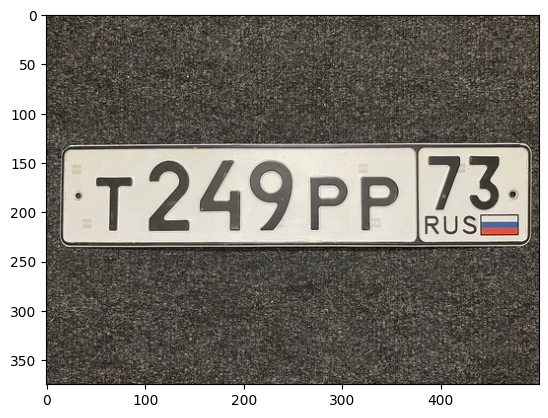

In [2]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_rgb)
plt.show()

## 3. Loading Haar Cascade Classifier

In [15]:
plate_cascade = cv2.CascadeClassifier('haarcascade_russian_plate_number.xml')

## 4. Detecting Objects in the Image

In [16]:
found = plate_cascade.detectMultiScale(img_gray, minSize=(20, 20))

## 5. Drawing Rectangles Around Detected Objects

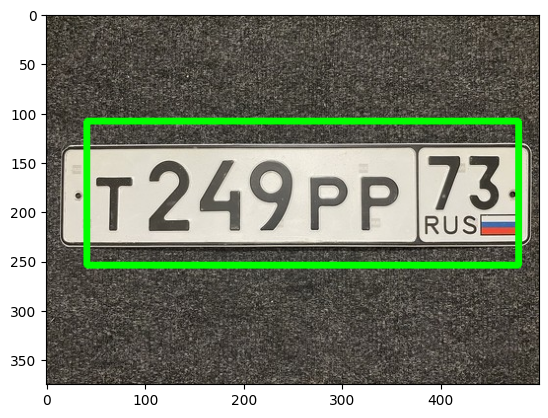

In [17]:
for (x, y, w, h) in found:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 5)

plt.imshow(img_rgb)
plt.show()

# Face Recognition

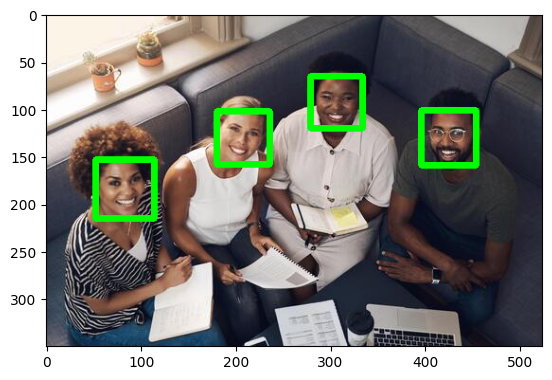

In [5]:
import cv2
import matplotlib.pyplot as plt   

img = cv2.imread("Face.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_rgb)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
found = face_cascade.detectMultiScale(img_gray, minSize=(20, 20))
for (x, y, w, h) in found:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 5)

plt.imshow(img_rgb)
plt.show()